# Sanity check: quijote nbody vs CHARM at 1 and 2 Gpc/h (lhid=663)

Three-way comparison:
- **quijote nbody** L1000-N128: ground-truth N-body halos
- **quijotelike charm6** L1000-N128: CHARM emulator on the same box
- **abacuslike charm6** L2000-N256: CHARM emulator on a larger box

All use lhid=663 and target a = 0.666667 (z ≈ 0.5).
Volume-normalized quantities (number density, mass function) should agree across boxes.

Checks: (1) file structure & halo counts, (2) halo mass function,
(3) cumulative number density, (4) projected spatial distribution,
(5) velocity PDFs, (6) concentration PDFs, (7) halo power spectrum vs CAMB.

Run with the **`cmass`** conda env.

In [21]:
import os
from os.path import join
import numpy as np
import h5py
import yaml
import matplotlib.pyplot as plt

LHID = 2000
A_TARGET = 0.666667
FIGDIR = '/u/maho3/git/ltu-gobig-notes/experiments/2026-07-09_sanity_nbody_vs_fastpm_L3000/figures'
os.makedirs(FIGDIR, exist_ok=True)

SUITES = [
    {
        'label':   'quijote L3000',
        'path':    f'/work/hdd/bdne/maho3/cmass-ili/quijote3gpch/nbody/L3000-N384/{LHID}/halos.h5',
        'cosmo':   f'/work/hdd/bdne/maho3/cmass-ili/quijote3gpch/nbody/L3000-N384/{LHID}/config.yaml',
        'L':       3000.0,
        'N_mesh':  384,
        'color':   'C3',
        'ls':      '-',
    },
    {
        'label':   'quijote nbody L1000',
        'path':    f'/work/hdd/bdne/maho3/cmass-ili/quijote/nbody/L1000-N128/{LHID}/halos.h5',
        'cosmo':   f'/work/hdd/bdne/maho3/cmass-ili/quijote/nbody/L1000-N128/{LHID}/config.yaml',
        'L':       1000.0,
        'N_mesh':  128,
        'color':   'C0',
        'ls':      '-',
    },
    # {
    #     'label':   'charm6 L1000',
    #     'path':    f'/work/hdd/bdne/maho3/cmass-ili/quijotelike/fastpm_charm6/L1000-N128/{LHID}/halos.h5',
    #     'cosmo':   f'/work/hdd/bdne/maho3/cmass-ili/quijotelike/fastpm_charm6/L1000-N128/{LHID}/config.yaml',
    #     'L':       1000.0,
    #     'N_mesh':  128,
    #     'color':   'C1',
    #     'ls':      '-',
    # },
    {
        'label':   'charm6 L3000',
        'path':    f'/work/hdd/bdne/maho3/cmass-ili/quijote3gpch/fastpm_charm6/L3000-N384/{LHID}/halos.h5',
        'cosmo':   f'/work/hdd/bdne/maho3/cmass-ili/quijote3gpch/fastpm_charm6/L3000-N384/{LHID}/config.yaml',
        'L':       3000.0,
        'N_mesh':  256,
        'color':   'C2',
        'ls':      '-',
    },
]

for s in SUITES:
    s['V'] = s['L'] ** 3

print(f'lhid={LHID},  a={A_TARGET}')
print(f'FIGDIR={FIGDIR}')

lhid=2000,  a=0.666667
FIGDIR=/u/maho3/git/ltu-gobig-notes/experiments/2026-07-09_sanity_nbody_vs_fastpm_L3000/figures


In [22]:
# --- helpers ---------------------------------------------------------------
def find_snap_key(hdf5_path, a_target):
    with h5py.File(hdf5_path, 'r') as f:
        keys = list(f.keys())
    return min(keys, key=lambda k: abs(float(k) - a_target))


def load_halos(suite):
    """Return (mass, pos, vel, conc, snap_key) for the closest snapshot to A_TARGET."""
    key = find_snap_key(suite['path'], A_TARGET)
    with h5py.File(suite['path'], 'r') as f:
        g = f[key]
        mass = g['mass'][:]
        pos = g['pos'][:]
        vel = g['vel'][:]
        conc = g['concentration'][:]
    return mass, pos, vel, conc, key


def load_cosmo(suite):
    with open(suite['cosmo']) as f:
        cfg = yaml.safe_load(f)
    return np.array(cfg['nbody']['cosmo'])


def mass_function(mass, volume, n_bins=40, m_min=None, m_max=None):
    m_min = m_min or mass.min() * 0.9
    m_max = m_max or mass.max() * 1.1
    log_edges = np.linspace(np.log10(m_min), np.log10(m_max), n_bins + 1)
    counts, _ = np.histogram(np.log10(mass), bins=log_edges)
    log_centers = 0.5 * (log_edges[:-1] + log_edges[1:])
    dlogM = log_edges[1] - log_edges[0]
    return 10 ** log_centers, counts / (dlogM * volume)

## 1. File structure, halo counts & cosmology

In [23]:
print(
    f"{'suite':>22} | {'snap key':>10} | {'N_halos':>10} | {'n [h/Mpc]^3':>14}")
print('-' * 68)
for s in SUITES:
    assert os.path.isfile(s['path']), f"MISSING: {s['path']}"
    m, pos, vel, conc, key = load_halos(s)
    assert np.isfinite(m).all() and np.isfinite(pos).all()
    assert (m > 0).all()
    print(f"{s['label']:>22} | {key:>10} | {len(m):>10,} | {len(m)/s['V']:.4e}")

print()
cosmos = [load_cosmo(s) for s in SUITES]
ref = cosmos[0]
print(f"{'suite':>22} | match vs quijote? | [Om, Ob, h, ns, s8]")
print('-' * 68)
for s, c in zip(SUITES, cosmos):
    match = np.allclose(ref, c, rtol=1e-4)
    print(f"{s['label']:>22} | {'OK' if match else 'MISMATCH':^17} | {np.round(c, 4).tolist()}")

                 suite |   snap key |    N_halos |    n [h/Mpc]^3
--------------------------------------------------------------------
         quijote L3000 |   0.666667 | 17,232,644 | 6.3825e-04
   quijote nbody L1000 |   0.666667 |    616,379 | 6.1638e-04
          charm6 L3000 |   0.666667 | 16,182,461 | 5.9935e-04

                 suite | match vs quijote? | [Om, Ob, h, ns, s8]
--------------------------------------------------------------------
         quijote L3000 |        OK         | [0.3175, 0.049, 0.6711, 0.9624, 0.834]
   quijote nbody L1000 |        OK         | [0.3175, 0.049, 0.6711, 0.9624, 0.834]
          charm6 L3000 |        OK         | [0.3175, 0.049, 0.6711, 0.9624, 0.834]


## 2. Halo mass function dN/dlogM/V

Volume-normalized; quijote nbody (solid) is the reference.
Both CHARM runs should reproduce the shape. High-mass end will differ between
L1000 and L2000 due to sample variance — the larger box has more rare massive halos.

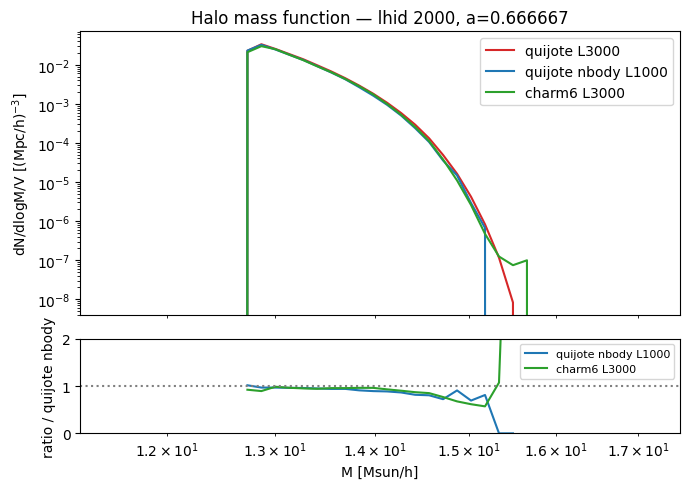

In [24]:
masses = [load_halos(s)[0] for s in SUITES]

M_MIN = min(m.min() for m in masses) * 0.9
M_MAX = max(m.max() for m in masses) * 1.1

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 5), sharex=True,
                               gridspec_kw={'height_ratios': [3, 1]})
hmfs = []
for s, m in zip(SUITES, masses):
    m_c, hmf = mass_function(m, s['V'], m_min=M_MIN, m_max=M_MAX)
    hmfs.append(hmf)
    ax1.loglog(m_c, hmf, color=s['color'], ls=s['ls'], label=s['label'])

ax1.set_ylabel('dN/dlogM/V [(Mpc/h)$^{-3}$]')
ax1.set_title(f'Halo mass function — lhid {LHID}, a={A_TARGET}')
ax1.legend()

ref_hmf = hmfs[0]
for s, hmf in zip(SUITES[1:], hmfs[1:]):
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = np.where(ref_hmf > 0, hmf / ref_hmf, np.nan)
    ax2.semilogx(m_c, ratio, color=s['color'], ls=s['ls'], label=s['label'])
ax2.axhline(1.0, color='grey', ls=':')
ax2.set_ylim(0, 2)
ax2.set_xlabel('M [Msun/h]')
ax2.set_ylabel('ratio / quijote nbody')
ax2.legend(fontsize=8)
plt.tight_layout()
fig.savefig(join(FIGDIR, 'halo_mass_function.jpg'), bbox_inches='tight')
plt.show()

## 3. Cumulative number density N(>M)/V

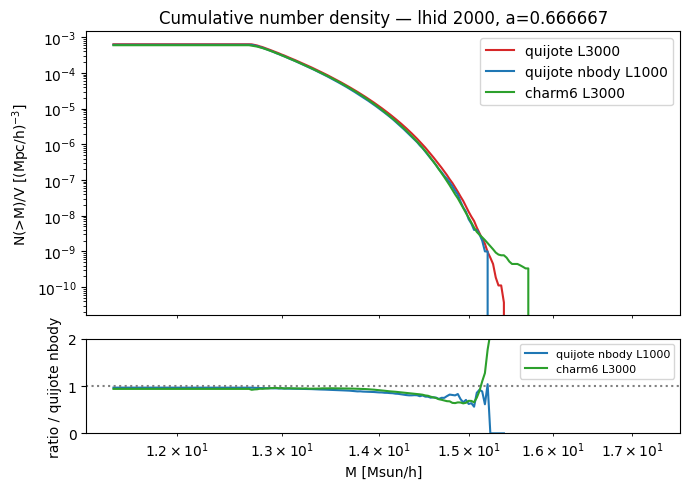

In [25]:
m_bins = 10 ** np.linspace(np.log10(M_MIN), np.log10(M_MAX), 200)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 5), sharex=True,
                               gridspec_kw={'height_ratios': [3, 1]})
cums = []
for s, m in zip(SUITES, masses):
    cum = np.array([(m > mb).sum() / s['V'] for mb in m_bins])
    cums.append(cum)
    ax1.loglog(m_bins, cum, color=s['color'], ls=s['ls'], label=s['label'])

ax1.set_ylabel('N(>M)/V [(Mpc/h)$^{-3}$]')
ax1.set_title(f'Cumulative number density — lhid {LHID}, a={A_TARGET}')
ax1.legend()

ref_cum = cums[0]
for s, cum in zip(SUITES[1:], cums[1:]):
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = np.where(ref_cum > 0, cum / ref_cum, np.nan)
    ax2.semilogx(m_bins, ratio, color=s['color'], ls=s['ls'], label=s['label'])
ax2.axhline(1.0, color='grey', ls=':')
ax2.set_ylim(0, 2)
ax2.set_xlabel('M [Msun/h]')
ax2.set_ylabel('ratio / quijote nbody')
ax2.legend(fontsize=8)
plt.tight_layout()
fig.savefig(join(FIGDIR, 'cumulative_number_density.jpg'), bbox_inches='tight')
plt.show()

## 4. Projected spatial distribution

Thin slab (2% of box depth). The L1000 panels share ICs (same lhid),
so filaments should align. The L2000 panel shows a larger region.

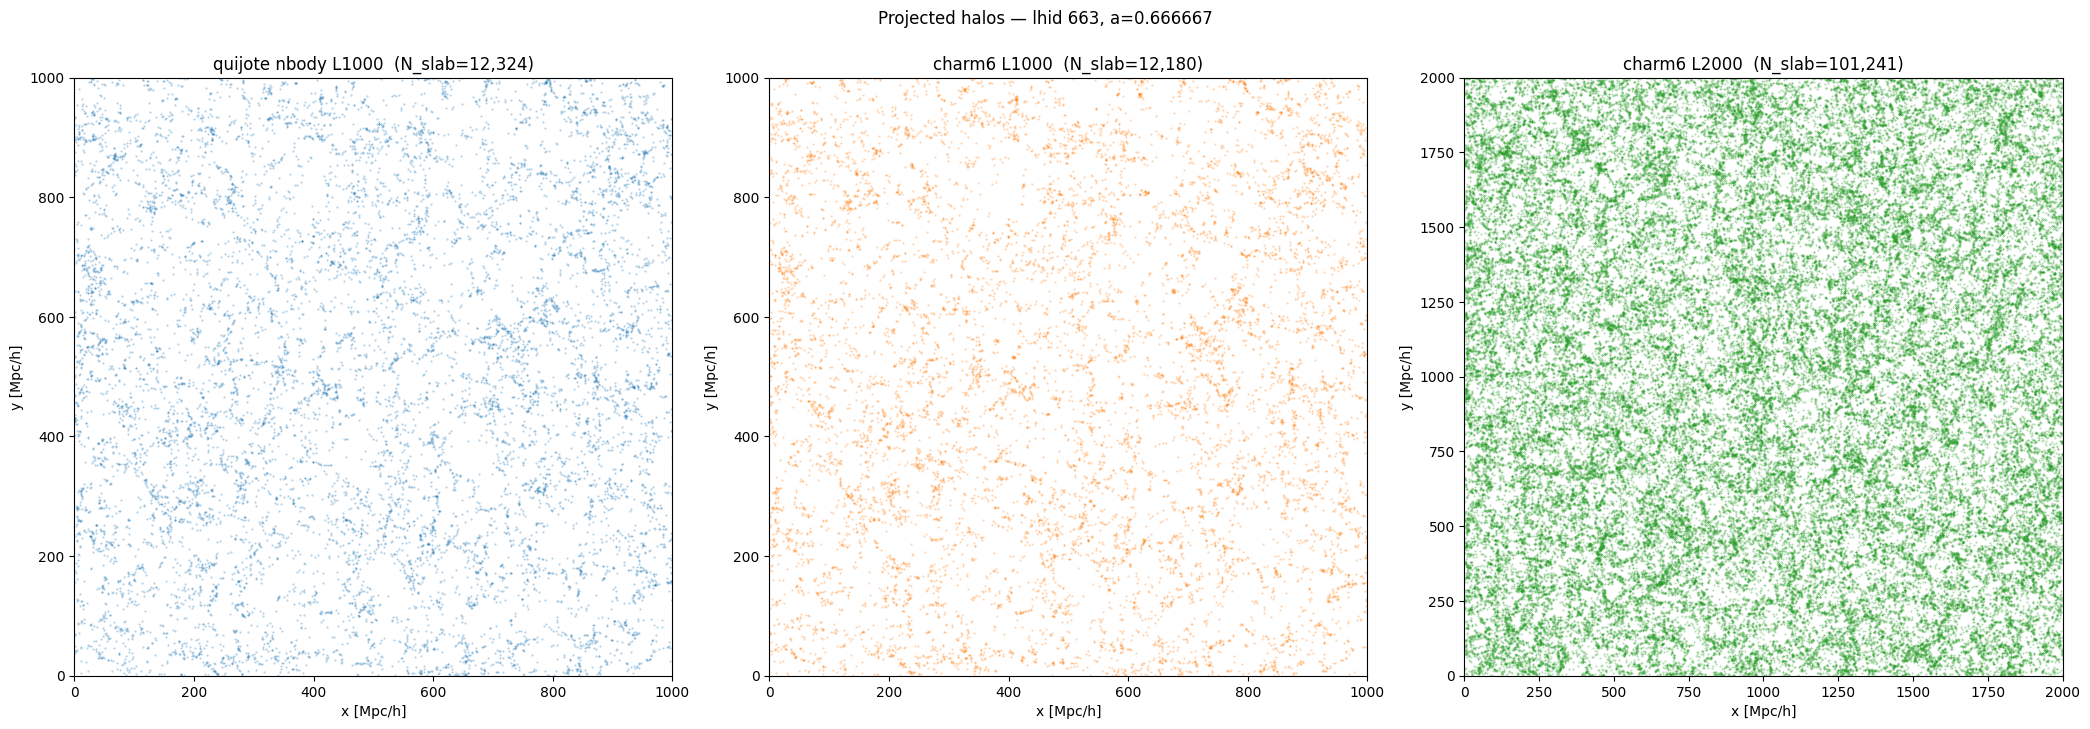

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(21, 7))
for ax, s in zip(axes, SUITES):
    L = s['L']
    _, pos, *_ = load_halos(s)
    slab = pos[:, 2] < 0.02 * L
    ax.scatter(pos[slab, 0], pos[slab, 1], s=0.2,
               alpha=0.4, color=s['color'], rasterized=True)
    ax.set_xlim(0, L)
    ax.set_ylim(0, L)
    ax.set_title(f"{s['label']}  (N_slab={slab.sum():,d})")
    ax.set_xlabel('x [Mpc/h]')
    ax.set_ylabel('y [Mpc/h]')
    ax.set_aspect('equal')
plt.suptitle(f'Projected halos — lhid {LHID}, a={A_TARGET}', y=1.01)
plt.tight_layout()
fig.savefig(join(FIGDIR, 'halo_distribution.jpg'), bbox_inches='tight')
plt.show()

## 5. Velocity PDFs

Per-component distributions should be zero-mean and roughly Gaussian.
The two L1000 suites share ICs → similar dispersions expected.

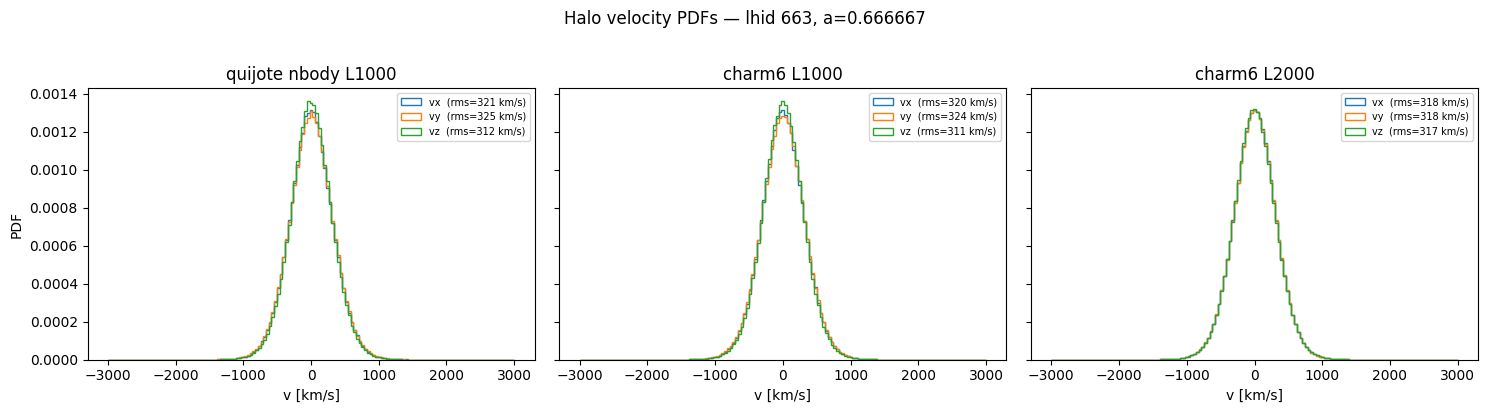

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
bins = np.linspace(-3000, 3000, 150)
for ax, s in zip(axes, SUITES):
    _, _, vel, *_ = load_halos(s)
    for i, c in enumerate('xyz'):
        ax.hist(vel[:, i], bins=bins, histtype='step', density=True,
                color=f'C{i}', label=f'v{c}  (rms={vel[:,i].std():.0f} km/s)')
    ax.set_title(s['label'])
    ax.set_xlabel('v [km/s]')
    ax.legend(fontsize=7)
axes[0].set_ylabel('PDF')
plt.suptitle(f'Halo velocity PDFs — lhid {LHID}, a={A_TARGET}', y=1.02)
plt.tight_layout()
fig.savefig(join(FIGDIR, 'halo_velocity_pdfs.jpg'), bbox_inches='tight')
plt.show()

## 6. Concentration PDFs

NFW concentration should be positive and peaked around 5–15.
The two CHARM runs should agree with each other; differences vs quijote nbody
reflect the different halo finder / concentration estimator.

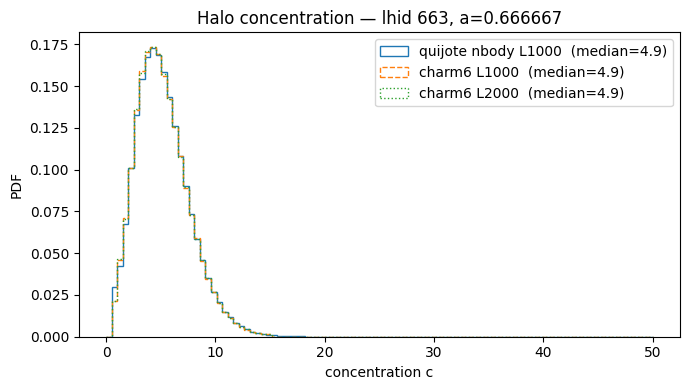

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
bins = np.linspace(0, 50, 100)
for s in SUITES:
    _, _, _, conc, _ = load_halos(s)
    ax.hist(conc, bins=bins, histtype='step', density=True,
            color=s['color'], ls=s['ls'],
            label=f"{s['label']}  (median={np.median(conc):.1f})")
ax.set_xlabel('concentration c')
ax.set_ylabel('PDF')
ax.set_title(f'Halo concentration — lhid {LHID}, a={A_TARGET}')
ax.legend()
plt.tight_layout()
fig.savefig(join(FIGDIR, 'halo_concentration_pdfs.jpg'), bbox_inches='tight')
plt.show()

## 7. Halo power spectrum vs CAMB linear theory

NGP-painted mesh; shot noise subtracted. Both CHARM runs should track the
quijote nbody curve. Nyquist limits differ by box size.

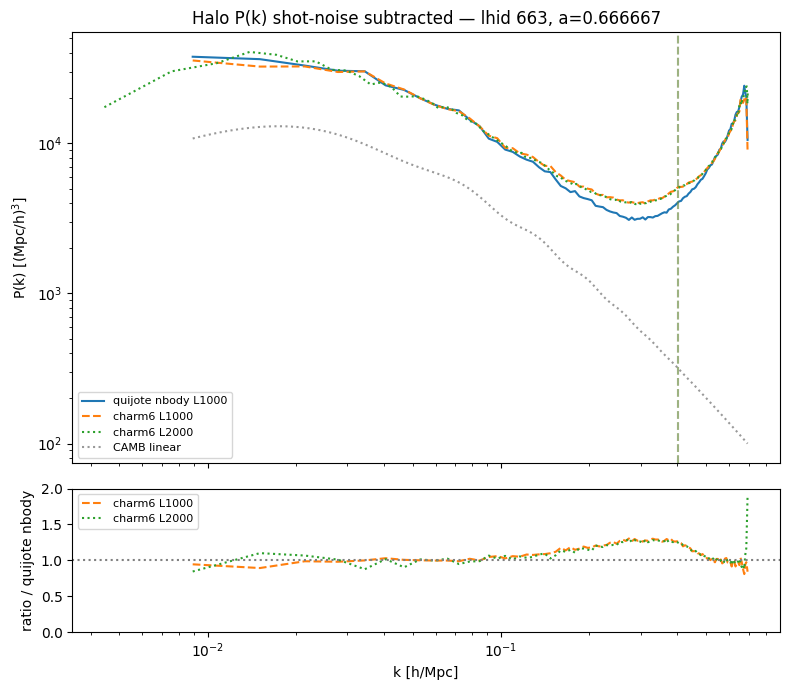

In [10]:
import Pk_library as PKL
from cmass.nbody.tools import get_camb_pk


def halo_pk(pos, L, n_mesh, threads=4):
    delta, _ = np.histogramdd(pos, bins=n_mesh, range=[(0, L)] * 3)
    delta = delta.astype(np.float32)
    delta /= delta.mean()
    delta -= 1.0
    pk_obj = PKL.Pk(delta, float(L), axis=0, MAS='NGP',
                    verbose=False, threads=threads)
    return pk_obj.k3D, pk_obj.Pk[:, 0]


z = 1.0 / A_TARGET - 1.0
cosmo_ref = load_cosmo(SUITES[0])  # quijote nbody
kcamb, pklin = None, None

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 7), sharex=True,
                               gridspec_kw={'height_ratios': [3, 1]})

pks = []
for s in SUITES:
    _, pos, *_ = load_halos(s)
    k, pk = halo_pk(pos, s['L'], s['N_mesh'])
    shot = s['V'] / len(pos)
    pks.append((k, pk - shot))

    ax1.loglog(k, pk - shot, color=s['color'], ls=s['ls'], label=s['label'])
    ax1.axvline(np.pi * s['N_mesh'] / s['L'], color=s['color'],
                ls='--', alpha=0.3)

    if kcamb is None:
        kcamb, pklin = get_camb_pk(k.astype(float), *cosmo_ref, z=z)

ax1.loglog(kcamb, pklin, color='grey', ls=':', alpha=0.8, label='CAMB linear')
ax1.set_ylabel('P(k) [(Mpc/h)$^3$]')
ax1.set_title(f'Halo P(k) shot-noise subtracted — lhid {LHID}, a={A_TARGET}')
ax1.legend(fontsize=8)

k_ref, pk_ref = pks[0]
for s, (k, pk) in zip(SUITES[1:], pks[1:]):
    pk_interp = np.interp(k_ref, k, pk, left=np.nan, right=np.nan)
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = np.where(pk_ref > 0, pk_interp / pk_ref, np.nan)
    ax2.semilogx(k_ref, ratio, color=s['color'], ls=s['ls'], label=s['label'])
ax2.axhline(1.0, color='grey', ls=':')
ax2.set_ylim(0, 2)
ax2.set_xlabel('k [h/Mpc]')
ax2.set_ylabel('ratio / quijote nbody')
ax2.legend(fontsize=8)
plt.tight_layout()
fig.savefig(join(FIGDIR, 'halo_power_spectra.jpg'), bbox_inches='tight')
plt.show()